<a href="https://colab.research.google.com/github/agustintamez/Actividades/blob/main/AF3_PIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF3: PIA- Sistema Mecatronico inteligente

#### Hora Clase: N5

**Integrantes del equipo:**
* Agustin Azael Tamez Galaviz 2173925 IMTC
* Diego Antonio Garcia Cardiel 2046605 IMTC
* Luis Angel Araujo Solis 1411762 IMTC
* Zuriel Emiliano Jasso Davila 2177803 IMTC
* Juan Pablo Flores Perez 19033468 IMTC

In [ ]:
# Paso 1: Instalación de librerías necesarias y carga de módulos de Machine Learning
!pip install scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import time

# Configuración de los pines lógicos simulados del ESP32 / Arduino
MQ5_PIN = 34
ALARMA_TEMP = 26
ALARMA_GAS = 27

print("Librerías e infraestructura del sistema listas.")

Librerías e infraestructura del sistema listas.


In [ ]:
# Paso 2: Creación de datos sintéticos para el entrenamiento de la IA
np.random.seed(42)
num_muestras = 600

# Simulación de un rango amplio de condiciones físicas
temperaturas = np.random.uniform(15, 65, num_muestras)
lecturas_gas = np.random.uniform(150, 4000, num_muestras)

# Lógica del clasificador: Peligro (1) si Temp > 40°C O si Gas > 2200. Estado Normal (0) en caso contrario.
etiquetas = np.where((temperaturas > 40) | (lecturas_gas > 2200), 1, 0)

# Construcción de la matriz de características y vectores de objetivos
datos_entrenamiento = pd.DataFrame({'Temperatura': temperaturas, 'Gas': lecturas_gas, 'Alarma': etiquetas})
X = datos_entrenamiento[['Temperatura', 'Gas']]
y = datos_entrenamiento['Alarma']

# Instanciamos el Árbol de Decisión limitando la profundidad para evitar sobreajuste
arbol_modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_modelo.fit(X, y)

print("Modelo entrenado con éxito.")

Modelo entrenado con éxito.


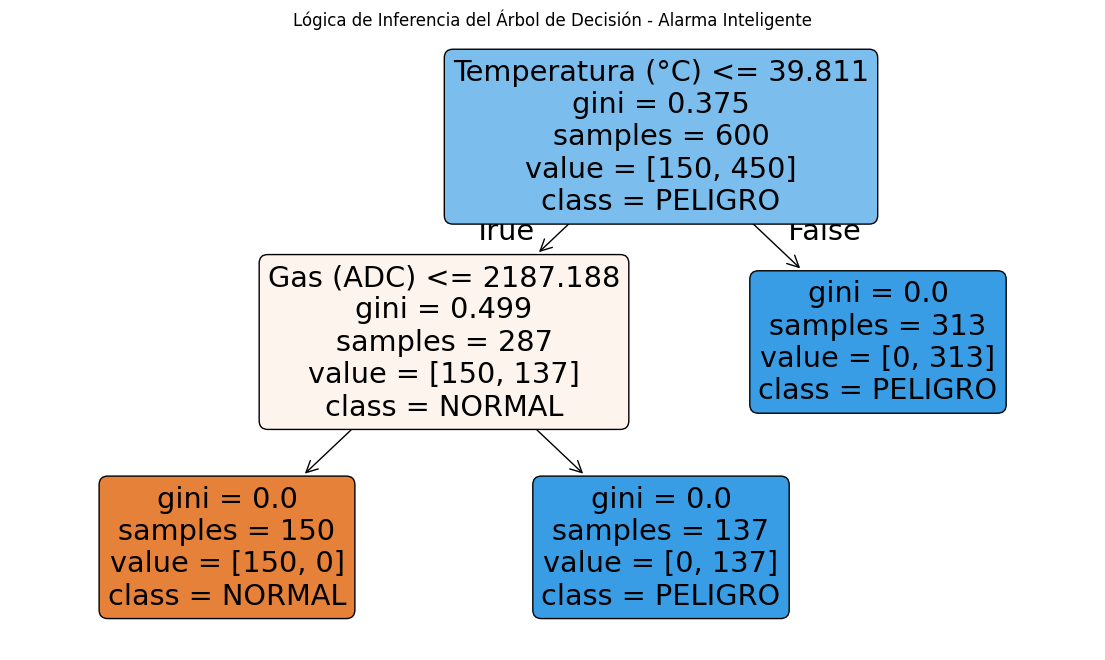

In [ ]:
# Paso 3: Visualización de las bifurcaciones y decisiones lógicas de la IA
plt.figure(figsize=(14, 8), dpi=100)
plot_tree(arbol_modelo,
          feature_names=['Temperatura (°C)', 'Gas (ADC)'],
          class_names=['NORMAL', 'PELIGRO'],
          filled=True,
          rounded=True)
plt.title("Lógica de Inferencia del Árbol de Decisión - Alarma Inteligente")
plt.show()

In [ ]:
# Paso 4: Definición de las rutinas de ejecución emulando el hardware original
def setup():
    print("\n" + "="*50)
    print("INICIALIZANDO MONITOREO INTELIGENTE")
    print("="*50)
    print("Puerto Serie establecido a 115200 baudios.")
    print(f"Pin ALARMA_TEMP ({ALARMA_TEMP}) inicializado en LOW.")
    print(f"Pin ALARMA_GAS ({ALARMA_GAS}) inicializado en LOW.")
    time.sleep(0.5)

def loop(temperatura_actual, lectura_gas_actual):
    # Lectura simulada de los canales analógicos/digitales
    temperatura = temperatura_actual
    gas = lectura_gas_actual

    # Inferencia basada en el árbol de decisión estructurado
    registro_entrada = np.array([[temperatura, gas]])
    prediccion = arbol_modelo.predict(registro_entrada)[0]

    print("-" * 40)
    print(f"[TELEMETRÍA] Sensor Temp: {temperatura:.1f} °C | Canal Gas: {gas:.0f}")

    # Conmutación de las salidas del circuito de alarmas
    if prediccion == 1:
        print(f"-> [OUTPUT PIN {ALARMA_TEMP}]: HIGH")
        print(f"-> [OUTPUT PIN {ALARMA_GAS}]: HIGH")
        print("🚨 ESTATUS: PELIGRO DETECTADO POR EL ÁRBOL DE DECISIÓN 🚨")
    else:
        print(f"-> [OUTPUT PIN {ALARMA_TEMP}]: LOW")
        print(f"-> [OUTPUT PIN {ALARMA_GAS}]: LOW")
        print("✅ ESTATUS: CONDICIONES DENTRO DEL RANGO NORMAL ✅")

# Ejecución de la rutina inicial
setup()

# Evaluación de los escenarios críticos solicitados
print("\n[TEST ESCENARIO 1: Temperatura Estable / Sin Gas]")
loop(25.0, 450)

print("\n[TEST ESCENARIO 2: Alta Temperatura en Habitación (Fuego)]")
loop(48.5, 400)

print("\n[TEST ESCENARIO 3: Fuga de Gas Detectada]")
loop(23.0, 3100)


INICIALIZANDO MONITOREO INTELIGENTE
Puerto Serie establecido a 115200 baudios.
Pin ALARMA_TEMP (26) inicializado en LOW.
Pin ALARMA_GAS (27) inicializado en LOW.

[TEST ESCENARIO 1: Temperatura Estable / Sin Gas]
----------------------------------------
[TELEMETRÍA] Sensor Temp: 25.0 °C | Canal Gas: 450
-> [OUTPUT PIN 26]: LOW
-> [OUTPUT PIN 27]: LOW
✅ ESTATUS: CONDICIONES DENTRO DEL RANGO NORMAL ✅

[TEST ESCENARIO 2: Alta Temperatura en Habitación (Fuego)]
----------------------------------------
[TELEMETRÍA] Sensor Temp: 48.5 °C | Canal Gas: 400
-> [OUTPUT PIN 26]: HIGH
-> [OUTPUT PIN 27]: HIGH
🚨 ESTATUS: PELIGRO DETECTADO POR EL ÁRBOL DE DECISIÓN 🚨

[TEST ESCENARIO 3: Fuga de Gas Detectada]
----------------------------------------
[TELEMETRÍA] Sensor Temp: 23.0 °C | Canal Gas: 3100
-> [OUTPUT PIN 26]: HIGH
-> [OUTPUT PIN 27]: HIGH
🚨 ESTATUS: PELIGRO DETECTADO POR EL ÁRBOL DE DECISIÓN 🚨


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
